# Boston House Price Prediction
### A complete regression project using Python and scikit-learn

**Course:** B.Tech CSE (AI & ML) - Machine Learning assignment (beginner level)
**Dataset file:** `data/HousingData.csv`
**Target:** `MEDV` (median house price)

> **How to read this notebook.** Every section has a short explanation in plain language, the code, its output and a short interpretation.
> The interpretations quote numbers that were observed when this notebook was run with the settings in `src/data_preprocessing.py`
> (`random_state=42`, `INCLUDE_B=False`). If you change those settings, re-run the notebook and re-read the interpretations.

## 1. Problem Statement

> *Using the provided dataset containing features such as a number of rooms, crime rates, and other relevant factors, design and implement a regression model to accurately predict Boston house prices. The solution should involve data preprocessing, model selection, training, and evaluation.*

In simple words: given facts about a neighbourhood (crime rate, average number of rooms, pupil-teacher ratio, ...), predict the median price of houses there.

## 2. Objective

1. Load and inspect the provided dataset without assuming its structure.
2. Clean and prepare the data (missing values, scaling) **without data leakage**.
3. Explore the data visually and find which features relate most strongly to price.
4. Train and compare five regression models: Linear, Ridge, Decision Tree, Random Forest, Gradient Boosting.
5. Evaluate them with MAE, MSE, RMSE and R², choose a final model and save it.
6. Build a prediction function (and a small Streamlit app) that uses the saved model.

## 3. Introduction

**Machine learning** lets a computer learn patterns from data instead of following hand-written rules.
This project uses **supervised learning**: every training example has *input features* (`X`) and a known *answer* (`y`, the price), and the model learns the mapping from `X` to `y`.

Because the price is a continuous number (for example 21.6 or 34.7) and not a category, this is a **regression** problem.
(If we were predicting a category such as "cheap / medium / expensive" it would be *classification*.)

The workflow used here is the standard one:

`Load data -> Inspect -> Clean / preprocess -> Explore -> Split into train and test -> Train several models -> Evaluate -> Pick the best -> Save -> Predict`

## 4. Dataset Description

The provided file is **`HousingData.csv`**. Its inspection (Section 7) shows 506 rows and 14 columns:
13 candidate input features and the target `MEDV`.

The file has no data dictionary. The column names match the well-known Boston Housing variables, so the standard meanings are listed below
(these descriptions come from the public documentation of that dataset, not from the file itself):

| Column | Meaning |
|---|---|
| CRIM | Per-capita crime rate by town |
| ZN | Share of residential land zoned for large lots |
| INDUS | Share of non-retail business acres per town |
| CHAS | 1 if the tract borders the Charles River, else 0 |
| NOX | Nitric-oxide concentration (air pollution) |
| RM | Average number of rooms per dwelling |
| AGE | Share of owner-occupied units built before 1940 |
| DIS | Weighted distance to five Boston employment centres |
| RAD | Index of accessibility to radial highways |
| TAX | Full-value property-tax rate |
| PTRATIO | Pupil-teacher ratio by town |
| B | A census-derived index based on the proportion of Black residents (see Section 8 for why it is excluded) |
| LSTAT | Percentage of lower-status population |
| **MEDV** | **Median value of owner-occupied homes - the target.** In the original dataset this is in $1000s; the file itself does not state the unit, so plots label it "$1000s" as an assumption. |

## 5. Import Libraries

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make the project's src/ folder importable (this notebook lives in notebooks/)
PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from data_preprocessing import (DATA_PATH, INCLUDE_B, RANDOM_STATE, TARGET_COLUMN,
                                TEST_SIZE, inspect_data, load_data, split_data,
                                split_xy)
from evaluate import (PLOTS_DIR, RESULTS_DIR, MODEL_PATH, evaluate_pipeline,
                      plot_actual_vs_predicted, plot_feature_importance,
                      plot_model_comparison, plot_residuals, plot_train_vs_test,
                      regression_metrics)
from train import (CV_FOLDS, build_pipelines, choose_best_model,
                   cross_validate_models, fit_and_evaluate, get_importances,
                   save_artifacts, tune_model)
from predict import format_price, load_metadata, predict_price

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name):
    """Save the current figure into outputs/plots/."""
    plt.gcf().savefig(PLOTS_DIR / name, dpi=150, bbox_inches="tight")


print("Libraries imported. Project root:", PROJECT_ROOT.name)

Libraries imported. Project root: Boston-House-Price-Prediction


**Why these libraries?** `pandas`/`numpy` handle tables and numbers, `matplotlib`/`seaborn` draw charts, `scikit-learn` provides the models, pipelines and metrics, and `joblib` saves the trained model.
The helper functions imported from `src/` are the same ones used by `python src/train.py`, so the notebook and the script always agree.

## 6. Load Dataset

In [2]:
df = load_data()
print("File:", DATA_PATH.name)
print("Shape (rows, columns):", df.shape)

File: HousingData.csv
Shape (rows, columns): (506, 14)


The file uses the text `NA` to mark missing values; `pandas` converts it to `NaN` ("not a number") automatically when reading, so we do not have to handle the text manually.

## 7. Dataset Inspection

In [3]:
info = inspect_data(df)
print("Number of rows   :", info["shape"][0])
print("Number of columns:", info["shape"][1])
print("Column names     :", info["columns"])
print("Duplicate rows   :", info["duplicate_rows"])
print("Constant columns :", info["constant_columns"] or "none")
print("Rows with at least one missing value:", info["rows_with_any_missing"],
      f"({info['rows_with_any_missing'] / len(df):.1%})")

Number of rows   : 506
Number of columns: 14
Column names     : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Duplicate rows   : 0
Constant columns : none
Rows with at least one missing value: 112 (22.1%)


In [4]:
# Data types and missing values side by side
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
})
summary

,dtype,missing,missing_%,unique_values
CRIM,float64,20,3.95,484
ZN,float64,20,3.95,26
INDUS,float64,20,3.95,76
CHAS,float64,20,3.95,2
NOX,float64,0,0.00,81
RM,float64,0,0.00,446
AGE,float64,20,3.95,348
DIS,float64,0,0.00,412
RAD,int64,0,0.00,9
TAX,int64,0,0.00,66


In [5]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [6]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0.0,0.573,6.030,NaN,2.5050,1,273,21.0,396.90,7.88,11.9


In [7]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
CRIM,486.0,3.612,8.720,0.006,0.082,0.254,3.560,88.976
ZN,486.0,11.212,23.389,0.000,0.000,0.000,12.500,100.000
INDUS,486.0,11.084,6.836,0.460,5.190,9.690,18.100,27.740
CHAS,486.0,0.070,0.255,0.000,0.000,0.000,0.000,1.000
NOX,506.0,0.555,0.116,0.385,0.449,0.538,0.624,0.871
RM,506.0,6.285,0.703,3.561,5.885,6.208,6.624,8.780
AGE,486.0,68.519,28.000,2.900,45.175,76.800,93.975,100.000
DIS,506.0,3.795,2.106,1.130,2.100,3.207,5.188,12.126
RAD,506.0,9.549,8.707,1.000,4.000,5.000,24.000,24.000
TAX,506.0,408.237,168.537,187.000,279.000,330.000,666.000,711.000


**Observations (from the output above)**

* The dataset has **506 rows and 14 columns**, with **no duplicate rows** and no constant columns.
* Every column is numeric. `CHAS` is stored as a decimal (`float64`) only because it contains missing values; its real values are 0 or 1.
* **Six columns (`CRIM`, `ZN`, `INDUS`, `CHAS`, `AGE`, `LSTAT`) each have 20 missing values (3.95 %)**. Together **112 of 506 rows (22 %)** have at least one missing value, so deleting incomplete rows would throw away a fifth of the data. We will impute instead.
* `CRIM` is very skewed: median 0.25 but maximum 88.98. `ZN` is 0 for at least half of the towns.
* The features are on very different scales (`NOX` is about 0.5, `TAX` is about 400), which matters for some models (Section 8).
* The target `MEDV` ranges from 5.0 to 50.0 with mean 22.53 and median 21.2.

### Target variable

The target should be the column we want to predict: the house price. Only `MEDV` fits that role: it is numeric, continuous, has no missing values, and it is the last column. We therefore treat **`MEDV` as the target** and everything else as input candidates.

In [8]:
target = df[TARGET_COLUMN]
print(target.describe().round(3))
print("\nSkewness:", round(target.skew(), 3))
print("Rows where MEDV equals its maximum (50.0):", int((target == target.max()).sum()))

count    506.000
mean      22.533
std        9.197
min        5.000
25%       17.025
50%       21.200
75%       25.000
max       50.000
Name: MEDV, dtype: float64

Skewness: 1.108
Rows where MEDV equals its maximum (50.0): 16


`MEDV` is **right-skewed** (skewness 1.11: a few very expensive areas pull the tail to the right), and **16 rows sit exactly at 50.0**. A pile-up of values at the maximum suggests the price was *capped* at 50, so the true prices of those areas may be higher. We keep these rows but will remember this when judging errors on expensive houses.

## 8. Data Preprocessing

Raw data is rarely ready for a model. Preprocessing is needed because:

* most scikit-learn models **cannot accept missing values**;
* models such as Linear/Ridge Regression are sensitive to **feature scales**;
* bad or irrelevant columns can reduce quality.

We check each item in turn.

### 8.1 Missing values

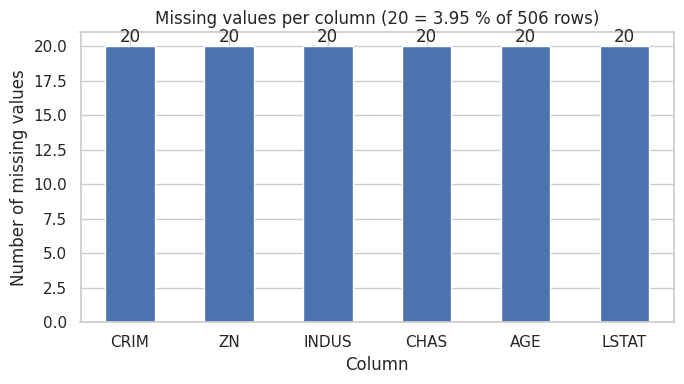

Mean MEDV, rows WITH a missing value   : 23.14
Mean MEDV, rows WITHOUT a missing value: 22.36


In [9]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

ax = missing.plot(kind="bar", color="#4C72B0", figsize=(7, 4))
ax.set_title("Missing values per column (20 = 3.95 % of 506 rows)")
ax.set_xlabel("Column")
ax.set_ylabel("Number of missing values")
plt.xticks(rotation=0)
for i, v in enumerate(missing.values):
    ax.text(i, v + 0.3, str(v), ha="center")
plt.tight_layout()
save_fig("01_missing_values.png")
plt.show()

# Is the missingness related to the price? (quick sanity check)
print("Mean MEDV, rows WITH a missing value   :", round(df[df.isna().any(axis=1)][TARGET_COLUMN].mean(), 2))
print("Mean MEDV, rows WITHOUT a missing value:", round(df.dropna()[TARGET_COLUMN].mean(), 2))

**Decision - imputation.** Six columns each miss 20 values. Rows with missing values have almost the same average price (23.14) as complete rows (22.36), so they do not look like a special group and dropping them would only waste data.
We therefore **impute** (fill in) the gaps:

* numeric columns -> the **median** of the training data (robust to outliers such as the extreme `CRIM` values);
* `CHAS` (a 0/1 flag) -> the **most frequent value**.

The imputer is placed *inside the model pipeline* (Section 8.5), so the medians are computed from the training rows only.

### 8.2 Data types, duplicates, constant columns

Section 7 already showed: all columns are numeric, there are **0 duplicate rows** and **no constant columns**, so nothing needs to be removed or converted. `CHAS` and `RAD` are discrete codes, but they are already numeric (0/1 and 1-24), so no encoding is required.

### 8.3 Outliers

In [10]:
def iqr_outlier_table(data):
    rows = []
    for col in data.columns:
        s = data[col].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        n = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
        rows.append((col, n, round(100 * n / len(s), 1)))
    return pd.DataFrame(rows, columns=["column", "IQR_outliers", "percent"]).set_index("column")

iqr_outlier_table(df).sort_values("IQR_outliers", ascending=False)

,IQR_outliers,percent
column,,
B,77,15.2
CRIM,65,13.4
ZN,63,13.0
MEDV,40,7.9
CHAS,34,7.0
RM,30,5.9
PTRATIO,15,3.0
LSTAT,7,1.4
DIS,5,1.0


The IQR rule flags values more than 1.5 x IQR beyond the quartiles. Among the model features, `CRIM` (65 values) and `ZN` (63, because most towns have 0) have the most flagged points, followed by `CHAS` (34: just the rare "1" class) and `RM` (30). `B` is also heavily flagged (77) but is excluded from the model (Section 8.4).
**We keep them.** They are real neighbourhoods (very high-crime areas, very small or large homes), not obvious typing errors, and tree-based models are not much affected by extreme values. Removing them would hide exactly the cases a price model should handle.

### 8.4 Column `B` and the choice of features

`B` is derived from the proportion of Black residents in each town. Using such a variable to estimate property value bakes a racial attribute into a model, which is ethically problematic (for this reason scikit-learn removed the original dataset from its library).
**We exclude `B` by default** and use the remaining **12 features**. Section 16.3 tests whether this costs any accuracy. To include `B`, set `INCLUDE_B = True` in `src/data_preprocessing.py`.

In [11]:
X, y = split_xy(df)
print("Input features X:", list(X.columns))
print("Target y        :", y.name)
print("Shapes          : X =", X.shape, ", y =", y.shape)
print("Include B?      :", INCLUDE_B)

Input features X: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']
Target y        : MEDV
Shapes          : X = (506, 12) , y = (506,)
Include B?      : False


### 8.5 Scaling, the Pipeline and data leakage

**Feature scaling.** `StandardScaler` rewrites each feature as `(value - mean) / standard deviation`, so all features have mean 0 and spread 1.
Linear and Ridge Regression benefit (Ridge's penalty treats all coefficients equally, so features must share a scale). **Tree-based models do not need scaling**, because they only compare a feature with thresholds and never combine features in a formula.
So we scale for Linear/Ridge and not for the tree models.

**Data leakage** means information from the test data sneaking into training. Example: if we computed the median or the scaling mean from *all* rows before splitting, the model would already know something about the test rows, making the test score look better than it really is.
The remedy is to **split first, then learn every preprocessing value (medians, means) from the training rows only.** scikit-learn's `Pipeline` does exactly this: `pipeline.fit(X_train, y_train)` learns the imputer/scaler from the training data, and `pipeline.predict(X_test)` only *applies* them.

## 9. Exploratory Data Analysis (EDA)

EDA means looking at the data before modelling. We keep it to the plots that answer useful questions.
(EDA uses the whole dataset for description only. No feature is chosen from it, and all 12 features go into the models, so it does not leak into the results.)

### 9.1 Distribution of the target

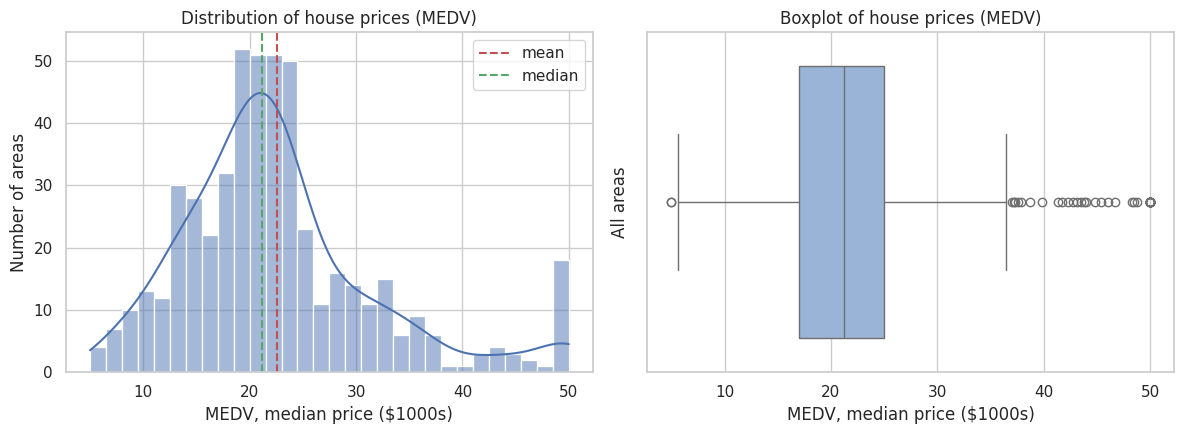

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df[TARGET_COLUMN], bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(df[TARGET_COLUMN].mean(), color="r", linestyle="--", label="mean")
axes[0].axvline(df[TARGET_COLUMN].median(), color="g", linestyle="--", label="median")
axes[0].set_title("Distribution of house prices (MEDV)")
axes[0].set_xlabel("MEDV, median price ($1000s)")
axes[0].set_ylabel("Number of areas")
axes[0].legend()

sns.boxplot(x=df[TARGET_COLUMN], ax=axes[1], color="#8FB3E0")
axes[1].set_title("Boxplot of house prices (MEDV)")
axes[1].set_xlabel("MEDV, median price ($1000s)")
axes[1].set_ylabel("All areas")
plt.tight_layout()
save_fig("02_target_distribution.png")
plt.show()

**Interpretation.** Most prices lie between about 17 and 25 (quartiles 17.0 and 25.0). The mean (22.5) is above the median (21.2), confirming the right skew. The boxplot flags 40 outlying values, and the spike at 50 is visible as a taller bar at the far right of the histogram, consistent with a capped maximum.

### 9.2 Correlation heatmap

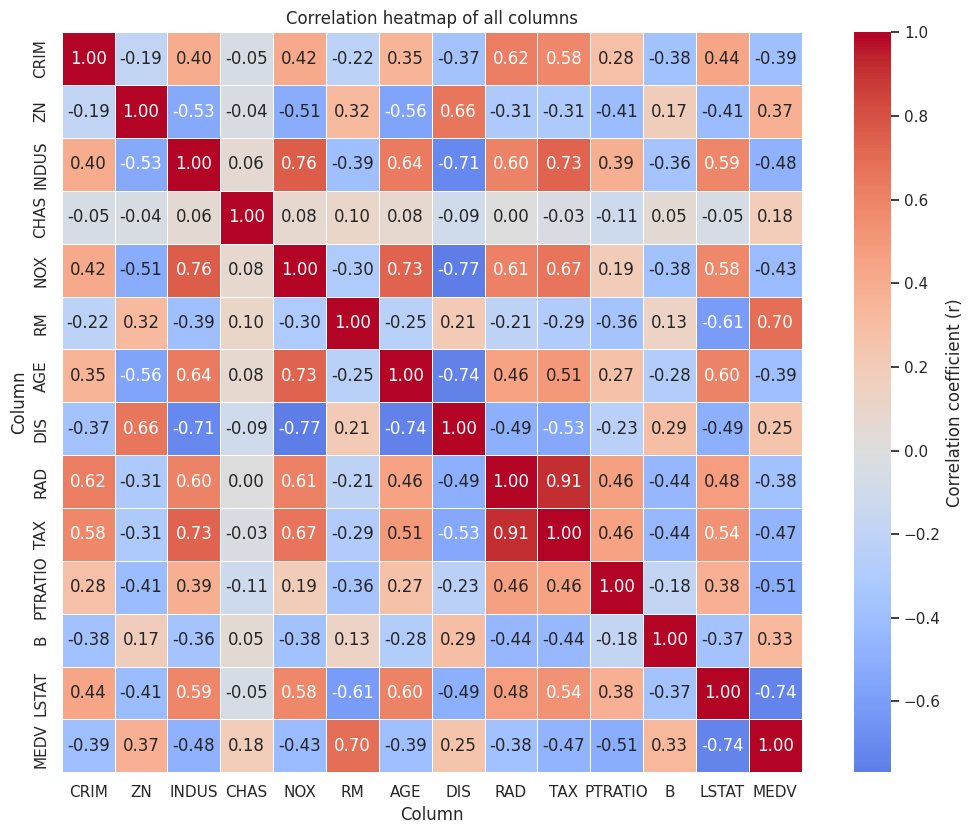

In [13]:
corr = df.corr()   # pandas ignores missing values pair by pair

plt.figure(figsize=(11, 8.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"label": "Correlation coefficient (r)"})
plt.title("Correlation heatmap of all columns")
plt.xlabel("Column")
plt.ylabel("Column")
plt.tight_layout()
save_fig("03_correlation_heatmap.png")
plt.show()

**Interpretation.** *Correlation* (r) measures how closely two columns move together, from -1 to +1.
The last row/column shows the relation with the price:
`RM` is positive (+0.70: more rooms, higher price) and `LSTAT` is strongly negative (-0.74: more lower-status population, lower price). `PTRATIO`, `INDUS` and `TAX` are moderately negative (about -0.47 to -0.51).
Several **features are also strongly correlated with each other** (for example `RAD`-`TAX` at 0.91), which is called *multicollinearity*. It makes individual coefficients in a linear model harder to interpret, though it does not stop prediction.

### 9.3 Selected features vs price

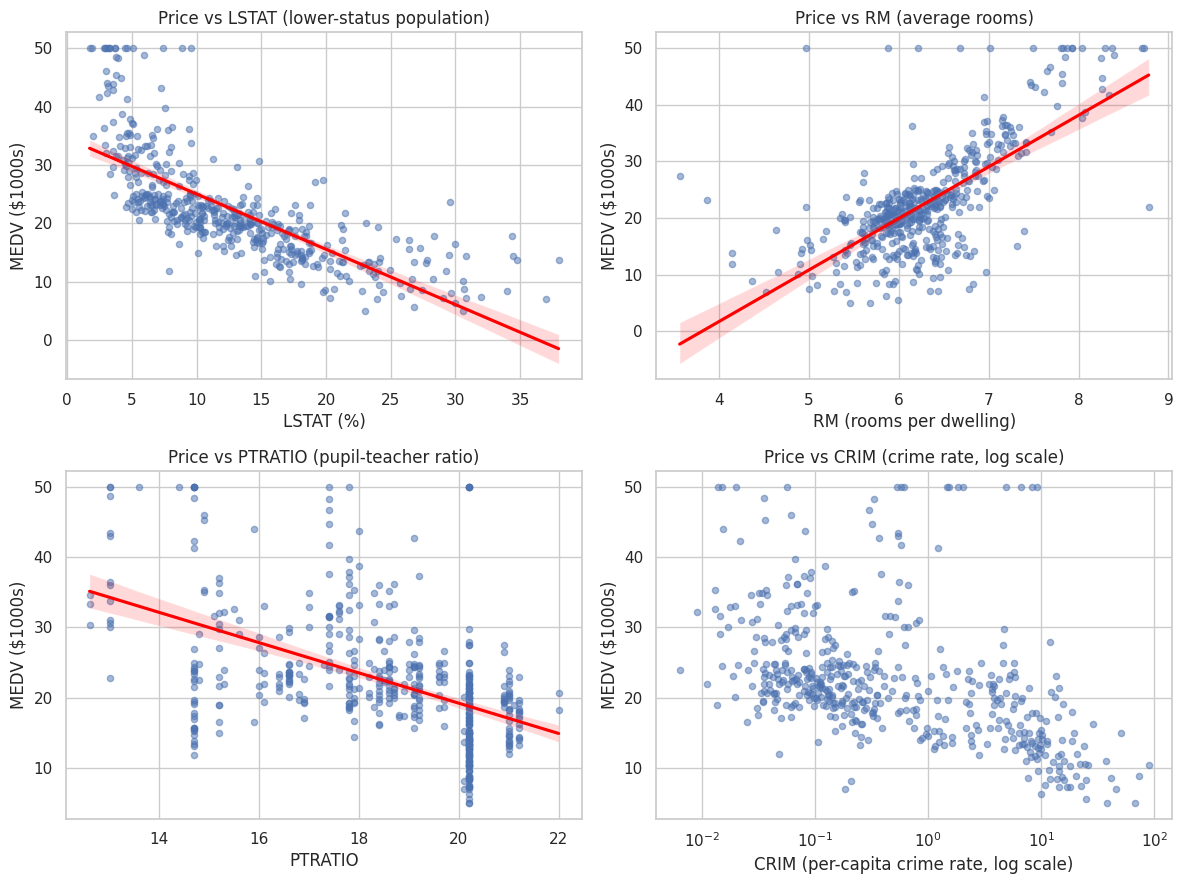

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.regplot(data=df, x="LSTAT", y=TARGET_COLUMN, ax=axes[0, 0],
            scatter_kws={"alpha": 0.5, "s": 20}, line_kws={"color": "red"})
axes[0, 0].set_title("Price vs LSTAT (lower-status population)")
axes[0, 0].set_xlabel("LSTAT (%)")
axes[0, 0].set_ylabel("MEDV ($1000s)")

sns.regplot(data=df, x="RM", y=TARGET_COLUMN, ax=axes[0, 1],
            scatter_kws={"alpha": 0.5, "s": 20}, line_kws={"color": "red"})
axes[0, 1].set_title("Price vs RM (average rooms)")
axes[0, 1].set_xlabel("RM (rooms per dwelling)")
axes[0, 1].set_ylabel("MEDV ($1000s)")

sns.regplot(data=df, x="PTRATIO", y=TARGET_COLUMN, ax=axes[1, 0],
            scatter_kws={"alpha": 0.5, "s": 20}, line_kws={"color": "red"})
axes[1, 0].set_title("Price vs PTRATIO (pupil-teacher ratio)")
axes[1, 0].set_xlabel("PTRATIO")
axes[1, 0].set_ylabel("MEDV ($1000s)")

axes[1, 1].scatter(df["CRIM"], df[TARGET_COLUMN], alpha=0.5, s=20)
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("Price vs CRIM (crime rate, log scale)")
axes[1, 1].set_xlabel("CRIM (per-capita crime rate, log scale)")
axes[1, 1].set_ylabel("MEDV ($1000s)")

plt.tight_layout()
save_fig("04_features_vs_price.png")
plt.show()

**Interpretation.**

* **RM:** price rises roughly linearly with the number of rooms.
* **LSTAT:** price falls as LSTAT rises, but the relation is *curved* (steep at low LSTAT, flatter later), so a straight line does not fit perfectly. This is one reason non-linear models can do better than Linear Regression.
* **PTRATIO:** a weaker downward trend with a lot of scatter.
* **CRIM:** on the log scale, higher crime rates go with lower prices. Areas priced below 15 have a median crime rate of 9.4, compared with 0.25 for the whole dataset. The row of points at exactly 50 is visible across the plots (the capped values).

### 9.4 Boxplots of important features

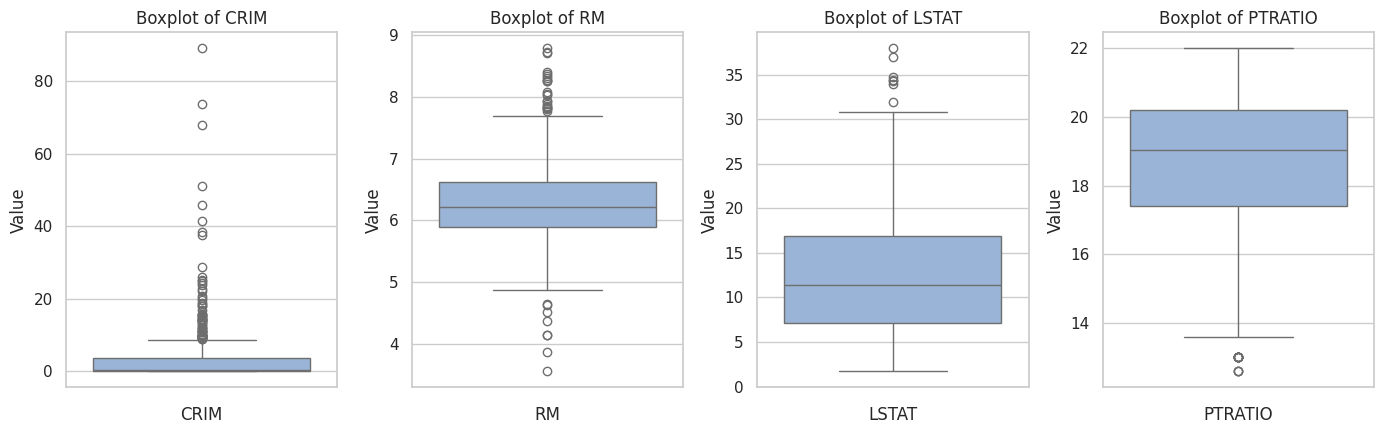

In [15]:
cols = ["CRIM", "RM", "LSTAT", "PTRATIO"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
for ax, col in zip(axes, cols):
    sns.boxplot(y=df[col], ax=ax, color="#8FB3E0")
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Value")
plt.tight_layout()
save_fig("05_feature_boxplots.png")
plt.show()

**Interpretation.** `CRIM` has a very compressed box near zero with many high outliers (heavily skewed). `RM` has outliers on both sides (very small and very large homes). `LSTAT` has a few high outliers, and `PTRATIO` a few low ones. These plots justify using the **median** for imputation and choosing models that cope with skewed features.

## 10. Feature Analysis

Which features have the strongest relationship with the price?

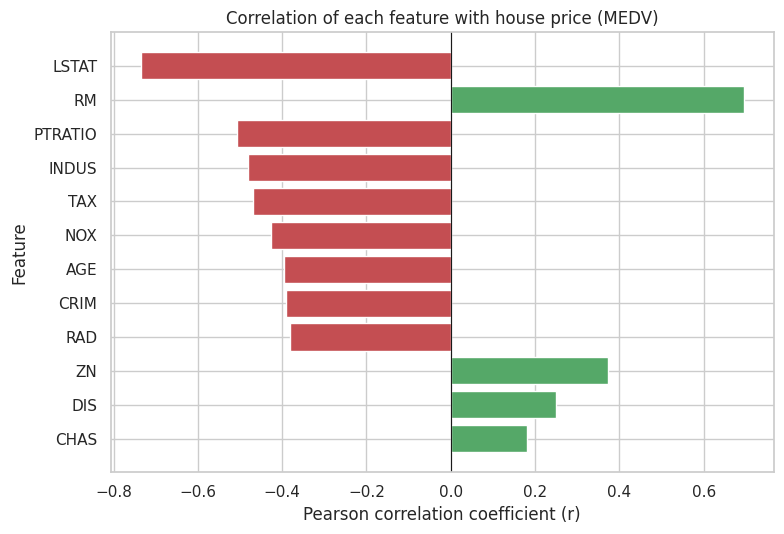

LSTAT     -0.736
RM         0.695
PTRATIO   -0.508
INDUS     -0.482
TAX       -0.469
NOX       -0.427
AGE       -0.395
CRIM      -0.391
RAD       -0.382
ZN         0.373
DIS        0.250
CHAS       0.181
Name: MEDV, dtype: float64

In [16]:
corr_with_target = (df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN)
                    .drop(labels=["B"], errors="ignore"))   # B is excluded from the model
order = corr_with_target.abs().sort_values(ascending=False).index

plt.figure(figsize=(8, 5.5))
colors = ["#C44E52" if v < 0 else "#55A868" for v in corr_with_target[order]]
plt.barh(order[::-1], corr_with_target[order][::-1], color=colors[::-1])
plt.axvline(0, color="k", linewidth=0.8)
plt.title("Correlation of each feature with house price (MEDV)")
plt.xlabel("Pearson correlation coefficient (r)")
plt.ylabel("Feature")
plt.tight_layout()
save_fig("06_correlation_with_target.png")
plt.show()

corr_with_target[order].round(3)

In [17]:
# Pairs of input features that are strongly correlated with each other (|r| > 0.7)
feature_corr = df.drop(columns=[TARGET_COLUMN, "B"]).corr()
pairs = [(a, b, round(feature_corr.loc[a, b], 2))
         for i, a in enumerate(feature_corr.columns)
         for b in feature_corr.columns[i + 1:]
         if abs(feature_corr.loc[a, b]) > 0.7]
pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation"])

,feature_1,feature_2,correlation
0,INDUS,NOX,0.76
1,INDUS,DIS,-0.71
2,INDUS,TAX,0.73
3,NOX,AGE,0.73
4,NOX,DIS,-0.77
5,AGE,DIS,-0.74
6,RAD,TAX,0.91


**Interpretation.**

* **Strongest linear relationships with price:** `LSTAT` (-0.74) and `RM` (+0.70), followed by `PTRATIO` (-0.51), `INDUS` (-0.48), `TAX` (-0.47) and `NOX` (-0.43). `CHAS` (+0.18) and `DIS` (+0.25) are weak.
* **Correlation is not causation.** For example, LSTAT and price move together, but that does not prove that changing LSTAT would change prices; both may be driven by other neighbourhood factors.
* **Redundant features:** `RAD`-`TAX` (0.91) and other pairs above carry overlapping information.

Tree-based feature importance (a second, non-linear view) needs a trained model, so it appears in Section 16.2 after training.

## 11. Train-Test Split

We hold back 20 % of the data as a **test set** that the model never sees during training. If we evaluated on the same data used for training, a model could simply memorise the answers and we would learn nothing about how it handles *new* houses.
An 80 : 20 split is a common convention that leaves enough data (404 rows) to learn from and enough (102 rows) for a meaningful test. `random_state=42` makes the shuffle repeatable.

In [18]:
X_train, X_test, y_train, y_test = split_data(df)
feature_names = list(X_train.columns)

print(f"Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows "
      f"({TEST_SIZE:.0%} test, random_state={RANDOM_STATE})")
print("\nTarget statistics in each split:")
print(pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).round(2))
print("\nMissing values per column (train / test):")
print(pd.DataFrame({"train": X_train.isna().sum(), "test": X_test.isna().sum()}).T)

Training set: 404 rows | Test set: 102 rows (20% test, random_state=42)

Target statistics in each split:
        train    test
count  404.00  102.00
mean    22.80   21.49
std      9.33    8.61
min      5.00    5.00
25%     16.95   17.12
50%     21.60   20.15
75%     26.40   24.08
max     50.00   50.00

Missing values per column (train / test):
       CRIM  ZN  INDUS  CHAS  NOX  RM  AGE  DIS  RAD  TAX  PTRATIO  LSTAT
train    18  17     18    16    0   0   16    0    0    0        0     15
test      2   3      2     4    0   0    4    0    0    0        0      5


The training and test targets have similar means (22.8 vs 21.5) and spreads (9.3 vs 8.6), so the split is reasonable. Both parts still contain missing values; the pipeline will fill them using **training medians only**.

## 12. Model Selection

We compare five regression models, from simple to more powerful. Trying several models is important because no single algorithm is best for every dataset.

| Model | How it works | Why test it | Advantages | Limitations |
|---|---|---|---|---|
| **Linear Regression** | Fits a straight-line formula `price = b0 + b1*x1 + b2*x2 + ...` by minimising squared errors | Simple baseline | Fast, easy to interpret | Cannot capture curved relationships; affected by correlated features |
| **Ridge Regression** | Linear Regression plus a penalty on large coefficients (`alpha` controls strength) | Handles correlated features better than plain linear | Stable, still interpretable | Still a straight-line model |
| **Decision Tree** | Repeatedly splits the data with yes/no questions (e.g. "LSTAT < 9.7?") until it reaches a price estimate | Captures non-linear patterns and interactions | Easy to visualise, no scaling needed | One deep tree overfits easily; we limit `max_depth=5` |
| **Random Forest** | Averages many trees, each trained on a random sample of rows and features | Reduces the overfitting of a single tree | Accurate, robust, gives feature importance | Slower, harder to interpret |
| **Gradient Boosting** | Builds trees one after another, each correcting the previous trees' mistakes | Often the strongest on tabular data | High accuracy | More settings to tune; can overfit; slower to train |

Linear and Ridge use a `StandardScaler`; the tree-based models do not (see Section 8.5). All five sit inside a pipeline that also does the imputation.

In [19]:
pipelines = build_pipelines(feature_names)
print("Models to compare:", list(pipelines))
print()
print(pipelines["Ridge Regression"])

Models to compare: ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['CRIM', 'ZN', 'INDUS', 'NOX',
                                                   'RM', 'AGE', 'DIS', 'RAD',
                                                   'TAX', 'PTRATIO', 'LSTAT']),
                                                 ('binary',
                                                  Pipeline(steps=[('impute',
                                                                   Simpl

## 13. Model Training

**Step 1 - Cross-validation.** A single train/test split can be lucky or unlucky. In *5-fold cross-validation* the training data is cut into 5 parts; each part takes a turn as a validation set while the model trains on the other 4. The average tells us how well a model generalises. **We use this on the training data only, so the test set cannot influence which model we pick.**

**Step 2 - Fit each model on the full training set** and record training and test predictions.

In [20]:
cv_table = cross_validate_models(pipelines, X_train, y_train)
cv_table.round(3)

,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean,CV_R2_std
Linear Regression,5.091,0.687,3.602,0.693,0.070
Ridge Regression,5.088,0.695,3.597,0.693,0.070
Decision Tree,6.141,0.587,3.648,0.528,0.177
Random Forest,4.125,0.496,2.621,0.794,0.057
Gradient Boosting,3.664,0.512,2.449,0.840,0.035


In [21]:
results = fit_and_evaluate(pipelines, X_train, y_train, X_test, y_test)
results = results.join(cv_table[["CV_RMSE_mean", "CV_R2_mean"]])
results.round(3)

,Train_MAE,Train_MSE,Train_RMSE,Train_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2,CV_RMSE_mean,CV_R2_mean
Linear Regression,3.463,23.250,4.822,0.732,3.079,23.659,4.864,0.677,5.091,0.693
Ridge Regression,3.460,23.251,4.822,0.732,3.075,23.673,4.865,0.677,5.088,0.693
Decision Tree,2.152,8.536,2.922,0.902,2.467,9.625,3.102,0.869,6.141,0.528
Random Forest,0.964,2.339,1.529,0.973,2.049,9.038,3.006,0.877,4.125,0.794
Gradient Boosting,1.122,2.063,1.436,0.976,1.906,7.386,2.718,0.899,3.664,0.840


**Interpretation.** The `Train_*` columns are measured on data the model has seen; the `Test_*` columns on unseen data. Training scores are always optimistic.
Random Forest and Gradient Boosting reach a training R² of about 0.97 but a test R² of about 0.88-0.90: a gap that is a mild sign of **overfitting** (learning training-specific detail).
Linear and Ridge have similar training and test scores (about 0.73 vs 0.68), which means they are **underfitting**: too simple to capture the non-linear structure.

## 14. Model Evaluation

| Metric | Meaning | Better is |
|---|---|---|
| **MAE** (Mean Absolute Error) | Average size of the prediction errors, ignoring direction | lower |
| **MSE** (Mean Squared Error) | Average of squared errors; punishes big mistakes heavily | lower |
| **RMSE** (Root MSE) | Square root of MSE - an error in the *same unit as the price* ($1000s) | lower |
| **R²** | Share of the variation in price the model explains (1 = perfect, 0 = no better than predicting the average) | higher |

We never choose a model by R² alone: RMSE/MAE tell us the typical error size, and the gap between training and test scores tells us about overfitting.

In [22]:
test_table = results[["Test_MAE", "Test_MSE", "Test_RMSE", "Test_R2"]].copy()
test_table.columns = ["MAE", "MSE", "RMSE", "R²"]
test_table.index.name = "Model"
test_table.round(3)

,MAE,MSE,RMSE,R²
Model,,,,
Linear Regression,3.079,23.659,4.864,0.677
Ridge Regression,3.075,23.673,4.865,0.677
Decision Tree,2.467,9.625,3.102,0.869
Random Forest,2.049,9.038,3.006,0.877
Gradient Boosting,1.906,7.386,2.718,0.899


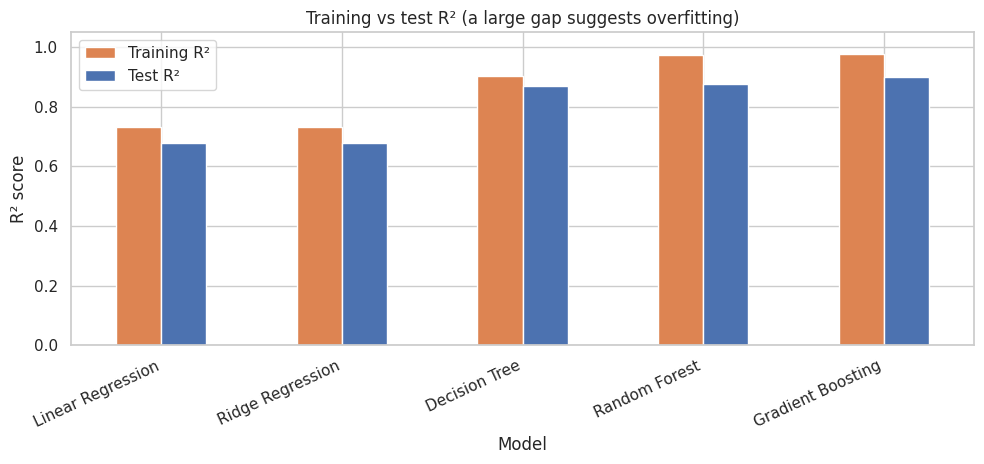

In [23]:
plot_train_vs_test(results, filename="train_vs_test_r2.png")
plt.show()

**Interpretation (test set).**

* Gradient Boosting has the lowest test errors (RMSE 2.72, MAE 1.91, R² 0.899), followed by Random Forest (RMSE 3.01) and the Decision Tree (RMSE 3.10).
* Linear and Ridge are clearly worse (RMSE about 4.86, R² 0.677) and nearly identical to each other, so Ridge's penalty adds little here.
* **A caution about the single test split:** the Decision Tree scores R² 0.869 on the test set but only 0.528 in cross-validation (with a large spread of 0.18 across folds). The 102-row test set is small, so one split can flatter a model. This is why cross-validation is used to choose the model.

## 15. Model Comparison

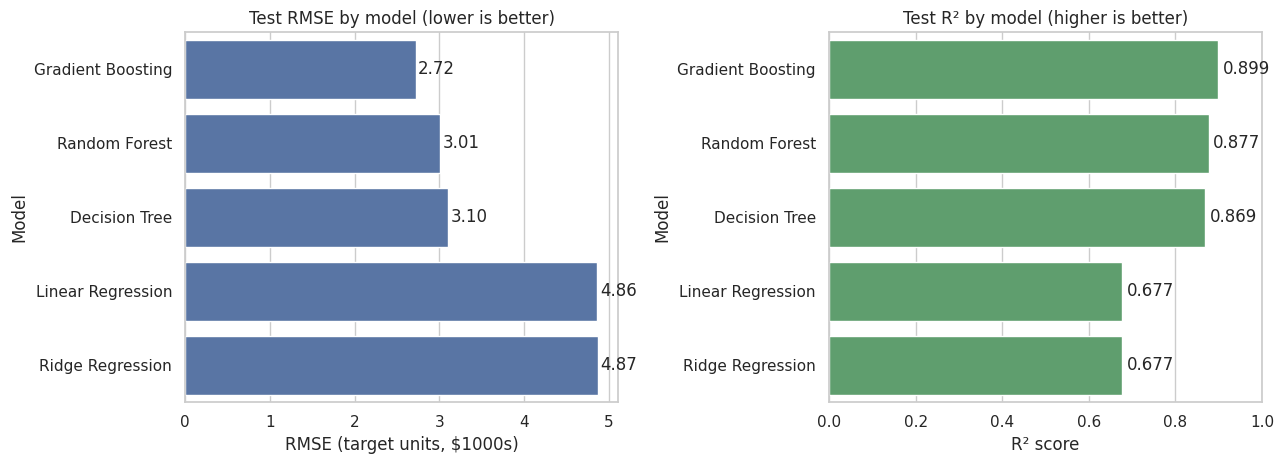

In [24]:
plot_model_comparison(results, filename=None)
plt.show()

In [25]:
cv_display = cv_table[["CV_RMSE_mean", "CV_RMSE_std", "CV_R2_mean", "CV_R2_std"]].round(3)
cv_display.sort_values("CV_RMSE_mean")

,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std
Gradient Boosting,3.664,0.512,0.840,0.035
Random Forest,4.125,0.496,0.794,0.057
Ridge Regression,5.088,0.695,0.693,0.070
Linear Regression,5.091,0.687,0.693,0.070
Decision Tree,6.141,0.587,0.528,0.177


**Observations.**

* Both the test-set and the cross-validation rankings put the models in nearly the same order: Gradient Boosting, then Random Forest, then the simpler models. The exception is the Decision Tree, which looks better on the test split than in cross-validation, as noted above.
* Cross-validated RMSE: Gradient Boosting 3.66, Random Forest 4.13, Linear/Ridge about 5.09, Decision Tree 6.14.
* The gap between Gradient Boosting and Random Forest is about one standard deviation of the fold-to-fold spread (about 0.5), so we should describe it as a modest advantage, not a decisive one.

## 16. Final Model

### 16.1 Choosing and tuning
The final model is chosen with **cross-validated RMSE on the training data**. We then tune its hyper-parameters with a small grid search (also cross-validated on training data). The test set is used only once, at the end.

In [26]:
best_name = choose_best_model(cv_table)
baseline_cv_rmse = cv_table.loc[best_name, "CV_RMSE_mean"]
print("Model with the lowest cross-validated RMSE:", best_name)

search = tune_model(best_name, build_pipelines(feature_names)[best_name], X_train, y_train)
tuned_cv_rmse = -search.best_score_
print(f"CV RMSE  default settings: {baseline_cv_rmse:.3f}")
print(f"CV RMSE  after tuning    : {tuned_cv_rmse:.3f}")
print("Best parameters:", search.best_params_)

tuned = bool(tuned_cv_rmse < baseline_cv_rmse)
final_pipeline = search.best_estimator_ if tuned else pipelines[best_name]
best_params = search.best_params_ if tuned else {}

Model with the lowest cross-validated RMSE: Gradient Boosting


CV RMSE  default settings: 3.664
CV RMSE  after tuning    : 3.596
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 400}


In [27]:
train_pred = final_pipeline.predict(X_train)
test_pred = final_pipeline.predict(X_test)
train_metrics = regression_metrics(y_train, train_pred)
test_metrics = regression_metrics(y_test, test_pred)

final_report = pd.DataFrame({"Training": train_metrics, "Test": test_metrics}).T
final_report.columns = ["MAE", "MSE", "RMSE", "R²"]
print("Final model:", best_name, "(tuned)" if tuned else "(default settings)")
final_report.round(4)

Final model: Gradient Boosting (tuned)


,MAE,MSE,RMSE,R²
Training,0.3747,0.2336,0.4833,0.9973
Test,1.8678,7.2459,2.6918,0.9012


**Why Gradient Boosting was selected.** It had the lowest cross-validated RMSE (3.66), the lowest cross-validated MAE, the highest cross-validated R² (0.84) and also the best test-set scores among the default models. The choice does not rest on R² alone: RMSE, MAE and cross-validation all agree.
Tuning lowered the cross-validated RMSE slightly (3.66 -> 3.60). The best settings (400 trees, learning rate 0.1) lie at the edge of the small grid, so a wider search could still improve things a little.

**Honest reading of the result.** On the test set the final model has RMSE 2.69 and R² 0.901, meaning typical predictions are off by roughly $1,900 (MAE 1.87 in $1000s), but it fits the training data almost perfectly (training R² 0.997). That large train-test gap shows the model is **overfitting to some degree**; the test score is the number that describes performance on new data.

In [28]:
# Add the tuned model to the comparison table, refresh the comparison plot, save tables
if tuned:
    tuned_row = evaluate_pipeline(final_pipeline, X_train, y_train, X_test, y_test)
    tuned_row["CV_RMSE_mean"] = tuned_cv_rmse
    results.loc[f"{best_name} (tuned)"] = pd.Series(tuned_row)

plot_model_comparison(results, filename="model_comparison.png")
plt.close("all")                      # (the same chart was shown above without the tuned bar)
plot_train_vs_test(results, filename="train_vs_test_r2.png")
plt.close("all")
results.to_csv(RESULTS_DIR / "model_comparison.csv")
cv_table.to_csv(RESULTS_DIR / "cv_results.csv")
results[["Test_MAE", "Test_MSE", "Test_RMSE", "Test_R2"]].round(3)

,Test_MAE,Test_MSE,Test_RMSE,Test_R2
Linear Regression,3.079,23.659,4.864,0.677
Ridge Regression,3.075,23.673,4.865,0.677
Decision Tree,2.467,9.625,3.102,0.869
Random Forest,2.049,9.038,3.006,0.877
Gradient Boosting,1.906,7.386,2.718,0.899
Gradient Boosting (tuned),1.868,7.246,2.692,0.901


### 16.2 Feature importance (tree-based)
A Random Forest counts how much each feature reduces prediction error across all its trees. This gives a **non-linear** view of which features matter, complementing the correlations in Section 10. It is computed on the **training data only**.

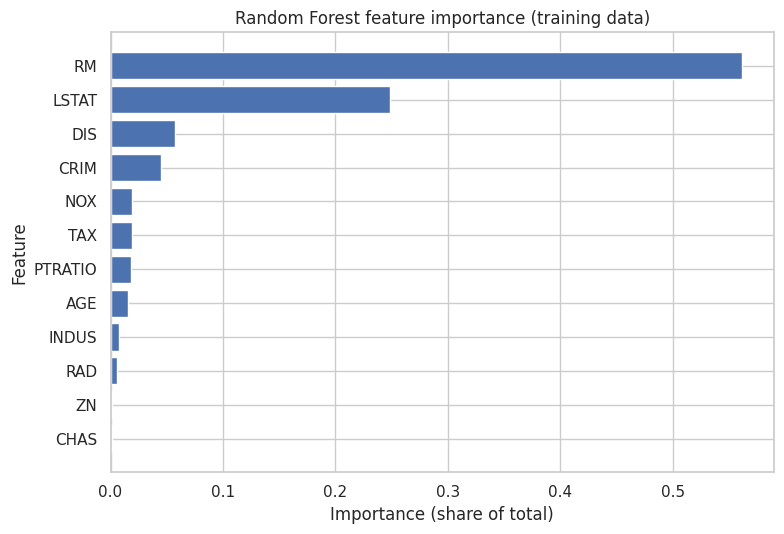

,Random Forest,Final Gradient Boosting
AGE,0.015,0.012
CHAS,0.001,0.001
CRIM,0.045,0.035
DIS,0.058,0.086
INDUS,0.008,0.003
LSTAT,0.249,0.277
NOX,0.019,0.035
PTRATIO,0.018,0.032
RAD,0.006,0.005
RM,0.562,0.499


In [29]:
rf_importance = get_importances(pipelines["Random Forest"])
gb_importance = get_importances(final_pipeline)

rf_importance.to_csv(RESULTS_DIR / "feature_importance_random_forest.csv", header=["importance"])
plot_feature_importance(rf_importance, "Random Forest feature importance (training data)")
plt.show()

pd.DataFrame({"Random Forest": rf_importance, "Final Gradient Boosting": gb_importance}).round(3)

**Interpretation.** In the Random Forest, **`RM` (0.56) and `LSTAT` (0.25) together account for about 81 % of the importance**; everything else is small (`DIS` 0.06, `CRIM` 0.05, others 0.02 or below). This agrees with the correlation analysis, which also put RM and LSTAT first.
Importance shows what the model *uses*, not what *causes* prices. Correlated features can also share importance between them.

### 16.3 Sensitivity check: does excluding column `B` cost accuracy?
We fit the same default Gradient Boosting model with and without `B` and compare the test scores.

In [30]:
from train import get_models
from data_preprocessing import make_pipeline
from sklearn.model_selection import train_test_split

X_with_b = df.drop(columns=[TARGET_COLUMN])
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_with_b, df[TARGET_COLUMN], test_size=TEST_SIZE, random_state=RANDOM_STATE)

rows = {}
for label, cols in [("Without B (used)", feature_names), ("With B", list(X_with_b.columns))]:
    pipe = make_pipeline(cols, get_models()["Gradient Boosting"][0], scale=False)
    pipe.fit(Xb_train[cols], yb_train)
    rows[label] = regression_metrics(yb_test, pipe.predict(Xb_test[cols]))
pd.DataFrame(rows).T.round(3)

,MAE,MSE,RMSE,R2
Without B (used),1.906,7.386,2.718,0.899
With B,1.899,7.191,2.682,0.902


Including `B` changes the test RMSE only from 2.72 to 2.68 (R² 0.899 vs 0.902), a difference too small to matter on a 102-row test set. Dropping it therefore costs essentially nothing in accuracy and avoids the ethical problem.

### 16.4 Save the final model

In [31]:
save_artifacts(final_pipeline, best_name, tuned, best_params, X_train, X_test,
               train_metrics, test_metrics, baseline_cv_rmse, tuned_cv_rmse)
print("Saved:", MODEL_PATH.relative_to(PROJECT_ROOT))
print("Saved: models/model_metadata.json, outputs/results/final_model_metrics.json")

# Reload the file and confirm it gives identical predictions
reloaded = joblib.load(MODEL_PATH)
print("Reloaded model reproduces predictions:", np.allclose(reloaded.predict(X_test), test_pred))

Saved: models/best_model.pkl
Saved: models/model_metadata.json, outputs/results/final_model_metrics.json
Reloaded model reproduces predictions: True


The saved file `best_model.pkl` is the **entire pipeline** (imputer -> model), not just the model. Any future prediction therefore gets exactly the same preprocessing as in training.
(`.pkl` files are Python pickles: only load model files from a source you trust.)

## 17. Actual vs Predicted

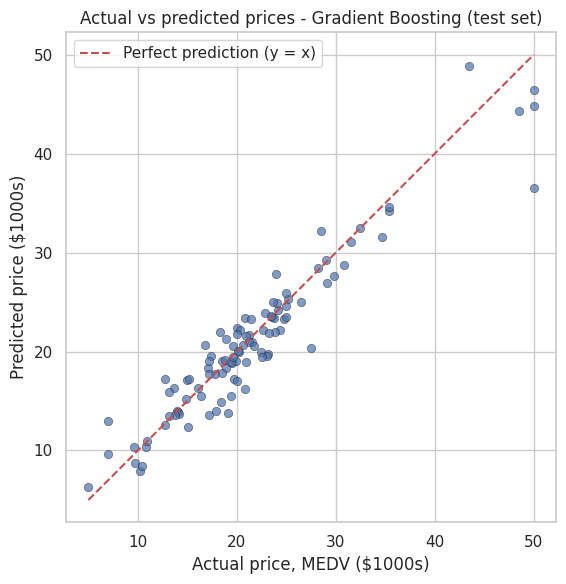

In [32]:
plot_actual_vs_predicted(y_test, test_pred,
                         f"Actual vs predicted prices - {best_name} (test set)")
plt.show()

**How to read it.** Each dot is one house from the test set. The dashed red line is *perfect prediction* (predicted = actual). A good model has dots **tightly clustered around that line** with no obvious curve or fan shape.

**Observation.** The dots follow the diagonal closely for most houses. The most visible miss is a house with actual price 50 that was predicted at about 36.5. That is one of the capped values discussed in Section 7, which the model cannot easily anticipate.

In [33]:
errors = pd.DataFrame({"actual": y_test.values, "predicted": test_pred.round(2)})
errors["error (actual - predicted)"] = (errors["actual"] - errors["predicted"]).round(2)
errors.reindex(errors["error (actual - predicted)"].abs().sort_values(ascending=False).index).head(5)

,actual,predicted,error (actual - predicted)
96,50.0,36.48,13.52
94,27.5,20.35,7.15
79,7.0,12.96,-5.96
54,43.5,48.84,-5.34
34,19.1,13.83,5.27


## 18. Residual Analysis

A **residual** is the prediction error for one house: `residual = actual - predicted`. Positive means the model predicted too low, negative too high.
We look for two things: are residuals centred around zero, and is there **any pattern** (for example errors growing with price), which would suggest the model is missing something systematic.

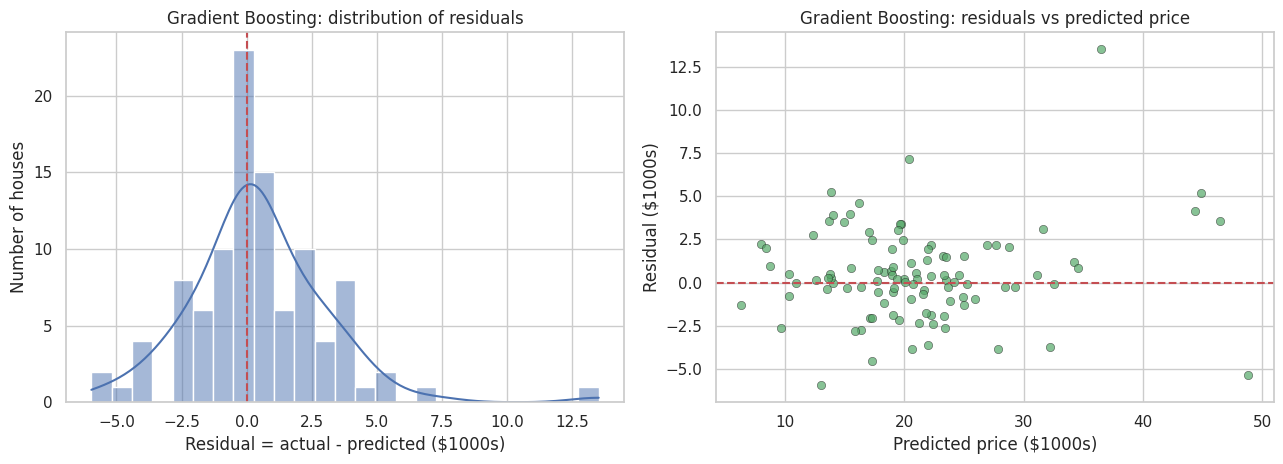

Mean residual        : 0.436
Std of residuals     : 2.656
Smallest / largest   : -5.96 / 13.52
Within +/-3 ($3,000) : 78.4%
Within +/-5 ($5,000) : 94.1%

Mean residual, houses priced >= 35: 3.3 (only 7 houses)
Mean residual, all other houses   : 0.22


In [34]:
_, residuals = plot_residuals(y_test, test_pred, best_name)
plt.show()

print("Mean residual        :", round(residuals.mean(), 3))
print("Std of residuals     :", round(residuals.std(), 3))
print("Smallest / largest   :", round(residuals.min(), 2), "/", round(residuals.max(), 2))
print("Within +/-3 ($3,000) :", f"{(np.abs(residuals) <= 3).mean():.1%}")
print("Within +/-5 ($5,000) :", f"{(np.abs(residuals) <= 5).mean():.1%}")

expensive = y_test.values >= 35
print("\nMean residual, houses priced >= 35:", round(residuals[expensive].mean(), 2),
      f"(only {expensive.sum()} houses)")
print("Mean residual, all other houses   :", round(residuals[~expensive].mean(), 2))

**Interpretation.**

* The residuals are centred close to zero (mean 0.44) with most in a narrow band: **78 % are within ±3 and 94 % within ±5** (in $1000s). The histogram is roughly bell-shaped with one long right tail.
* The largest residual (+13.5) is the capped-price house from Section 17; the remaining residuals lie between about -6 and +7.
* In the residual-vs-predicted plot most points form an unstructured cloud around zero. The few highest-priced houses tend to have positive residuals (the model under-predicts expensive areas: mean +3.3 for the 7 test houses priced at 35 or more). With only 7 such houses this is a hint, not a proven pattern.
* We do not claim the model satisfies any formal statistical assumptions; the plots only show that, on this test set, errors have no strong visible structure apart from the expensive tail.

## 19. Example Prediction

`predict_price()` (in `src/predict.py`) loads the saved pipeline, checks the inputs and returns a price. A value of `None` is treated as missing and imputed with the training median.

In [35]:
# (a) A real house from the held-out test set, so we can compare with the truth
sample = X_test.iloc[0].where(X_test.iloc[0].notna(), None).to_dict()
print("Input features:", sample)
print("\nPredicted price:", format_price(predict_price(sample)))
print("Actual price   :", format_price(float(y_test.iloc[0])))

Input features: {'CRIM': 0.09178, 'ZN': 0.0, 'INDUS': nan, 'CHAS': 0.0, 'NOX': 0.51, 'RM': 6.416, 'AGE': nan, 'DIS': 2.6463, 'RAD': 5.0, 'TAX': 296.0, 'PTRATIO': 16.6, 'LSTAT': 9.04}

Predicted price: $23,478  (23.48 in $1000s)
Actual price   : $23,600  (23.60 in $1000s)


In [36]:
# (b) A made-up house typed in by hand (values chosen inside the training ranges)
new_house = {"CRIM": 0.10, "ZN": 0.0, "INDUS": 7.0, "CHAS": 0, "NOX": 0.50,
             "RM": 6.5, "AGE": 60.0, "DIS": 4.0, "RAD": 4, "TAX": 300,
             "PTRATIO": 18.0, "LSTAT": 10.0}
print("Predicted price:", format_price(predict_price(new_house)))

Predicted price: $22,026  (22.03 in $1000s)


Case (a) uses a real test house (its inputs include missing values that the pipeline filled in). Case (b) is a hypothetical house: there is no true price to compare with, so it only demonstrates the mechanics. The same function powers the command-line tool and the Streamlit app (`streamlit run app.py`).

## 20. Conclusion

* The provided dataset (506 rows, 12 model features after excluding `B`) was inspected, cleaned and used to train five regression models inside leak-free pipelines.
* **Gradient Boosting** was selected using cross-validation on the training data (CV RMSE 3.66, tuned 3.60). On the untouched test set the tuned model achieved **MAE 1.87, RMSE 2.69, R² 0.901** (prices in $1000s, assuming the original dataset's unit).
* Non-linear tree ensembles clearly outperformed Linear and Ridge Regression (test RMSE about 4.9), which indicates non-linear relationships in the data.
* **`RM` (rooms) and `LSTAT` (lower-status population)** were the most influential features in both the correlation analysis and the Random Forest.
* **Limitations:** the model overfits noticeably (training R² 0.997 vs test 0.901); the test set has only 102 rows; the price appears capped at 50, so expensive areas are under-predicted; the data is an old, small snapshot of one city, so the model must not be used for real valuations; and correlations do not imply causation.

## 21. Future Scope

* Use **repeated cross-validation** or a wider hyper-parameter search (the best settings sat at the edge of the grid).
* Try other models such as XGBoost / LightGBM and stacking.
* Impute missing values with a model-based imputer (e.g. `IterativeImputer` or KNN) and compare.
* Add regularisation or stronger validation to reduce overfitting.
* Apply a transformation (e.g. log) to the skewed target and to `CRIM`.
* Explain individual predictions (e.g. SHAP values) and add prediction intervals.
* Validate on a modern, larger housing dataset and deploy the Streamlit app online.